<a href="https://colab.research.google.com/github/bishalkshah70-art/AI-and-Ml-/blob/main/Convolution_FUNDAMENTAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from skimage import data #Built-in image datasets

In [ ]:
def custom_convolve2d(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(
            image,
            pad_width=padding,
            mode='constant',
            constant_values=0
        )

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1

    out = np.zeros((out_h, out_w))

    feature_map=np.zeros((out_h,out_w))

    for y in range(out_h):
        for x in range(out_w):
          y_start=y*stride
          y_end=y_start+k_h
          x_start=x*stride
          x_end=x_start+k_w


          region=image[y_start:y_end,x_start:x_end]


          feature_map[y,x]=np.sum(region*kernel)


    return out

array([[200, 200, 200, ..., 189, 190, 190],
       [200, 199, 199, ..., 190, 190, 190],
       [199, 199, 199, ..., 190, 190, 190],
       ...,
       [ 25,  25,  27, ..., 139, 122, 147],
       [ 25,  25,  26, ..., 158, 141, 168],
       [ 25,  25,  27, ..., 151, 152, 149]], dtype=uint8)
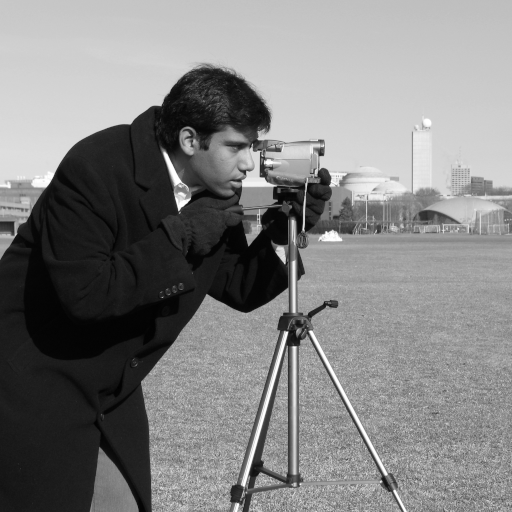

In [ ]:
gray_img = data.camera()
gray_img

In [ ]:
gray_img =gray_img.astype(np.float32)
gray_img

array([[200., 200., 200., ..., 189., 190., 190.],
       [200., 199., 199., ..., 190., 190., 190.],
       [199., 199., 199., ..., 190., 190., 190.],
       ...,
       [ 25.,  25.,  27., ..., 139., 122., 147.],
       [ 25.,  25.,  26., ..., 158., 141., 168.],
       [ 25.,  25.,  27., ..., 151., 152., 149.]], dtype=float32)

In [ ]:
import cv2
import numpy as np

# Assuming gray_img is already a grayscale image

# Vertical Sobel (detects vertical edges)
feat_vertical = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
feat_vertical = cv2.convertScaleAbs(feat_vertical)

# Horizontal Sobel (detects horizontal edges)
feat_horizontal = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)
feat_horizontal = cv2.convertScaleAbs(feat_horizontal)

# Sharpen
kernel = np.array([[0, -1, 0],
                   [-1, 5, -1],
                   [0, -1, 0]])
feat_sharpen = cv2.filter2D(gray_img, -1, kernel)

# 5×5 Box Blur
feat_blur = cv2.blur(gray_img, (5, 5))

In [ ]:
sobel_vertical = np.array([
[-1, 0, 1],
[-2, 0, 2],
[-1, 0, 1]
], dtype=np.float32)

In [ ]:
sobel_horizontal = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
],dtype=np.float32)


In [ ]:
sharpen_kernel = np.array([
    [0,-1,0],
    [-1,5,-1],
    [0,-1,0]
],dtype=np.float32)

In [ ]:
blur_kernel = np.ones((5,5),dtype=np.float32)/25.0

In [ ]:
feat_verticle=custom_convolve2d(gray_img,sobel_horizontal,stride=1,padding=1)
feat_horizontal=custom_convolve2d(gray_img,sobel_horizontal.T,stride=1,padding=1)
feat_sharpen=custom_convolve2d(gray_img,sharpen_kernel,stride=1,padding=1)
feat_blur=custom_convolve2d(gray_img,blur_kernel,stride=1,padding=1)

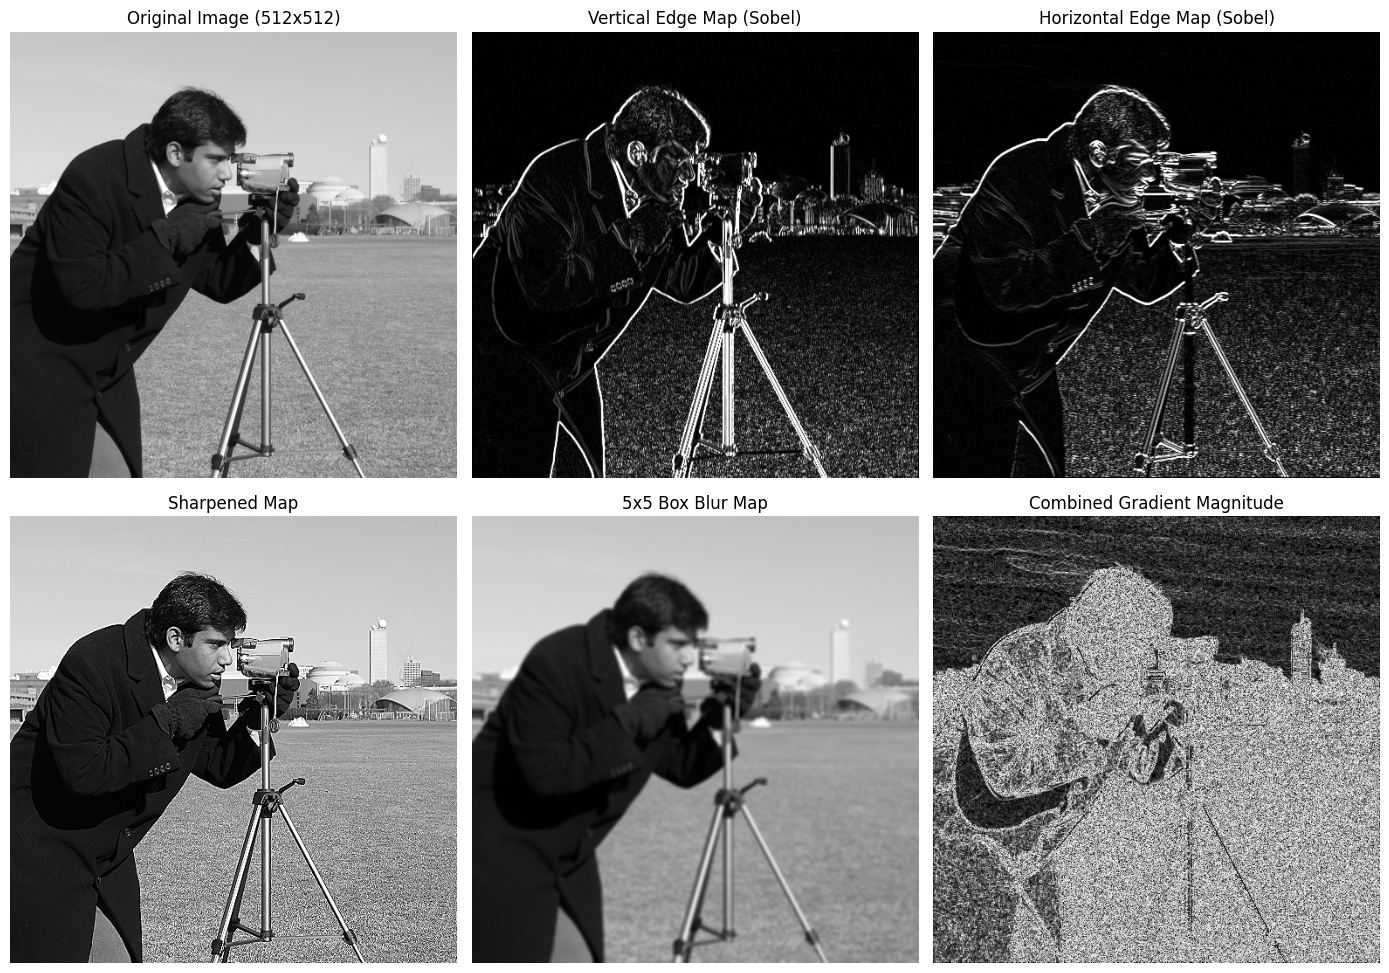

In [ ]:
plt.figure(figsize=(14, 10))
plt.subplot(2, 3, 1)
plt.title("Original Image (512x512)")
plt.imshow(gray_img, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.title("Vertical Edge Map (Sobel)")
plt.imshow(feat_vertical, cmap="gray")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.title("Horizontal Edge Map (Sobel)")
plt.imshow(feat_horizontal, cmap="gray")
plt.axis("off")


plt.subplot(2, 3, 4)
plt.title("Sharpened Map")
plt.imshow(np.clip(feat_sharpen, 0, 255), cmap="gray")
plt.axis("off")


plt.subplot(2, 3, 5)
plt.title("5x5 Box Blur Map")
plt.imshow(feat_blur, cmap="gray")
plt.axis("off")


# Combined Magnitude Map: sqrt(V^2 + H^2)
edge_magnitude = np.sqrt(feat_vertical**2 + feat_horizontal**2)
plt.subplot(2, 3, 6)
plt.title("Combined Gradient Magnitude")
plt.imshow(edge_magnitude, cmap="gray")
plt.axis("off")


plt.tight_layout()
plt.show()
